# 📚 Book Genre Classification with BERT
### Multiclass Text Classification using HuggingFace Transformers + PyTorch

**Architecture:** DistilBERT-base-uncased fine-tuned for 21-class genre classification  
**Input:** `title` + `text_sample` (combined)  
**Target:** `target_genre` (21 classes)  
**Dataset Size:** ~7,000 samples

---
### 📋 Table of Contents
1. Environment Setup & Installations
2. Imports & Configuration
3. Data Loading & Exploration
4. Preprocessing Pipeline
5. Dataset & DataLoader
6. Model Architecture
7. Training Infrastructure
8. Training Loop
9. Evaluation & Metrics
10. Model Save & Load
11. Inference on New Books
12. Tips & Hyperparameter Guide

## 1. 📦 Environment Setup & Installations

## 2. 📥 Imports & Global Configuration

In [99]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import json
import time
import warnings
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

warnings.filterwarnings("ignore")

# ── Data & Math ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── ML Utilities ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import (
    CosineAnnealingLR, LinearLR, SequentialLR
)

# ── HuggingFace Transformers ───────────────────────────────────────────────────
from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup,
)

# ── Progress Bar ──────────────────────────────────────────────────────────────
from tqdm.auto import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILITY — fix all random seeds for consistent results
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    """Seed everything for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)


# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL HYPERPARAMETERS — all tunable values in one place
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL HYPERPARAMETERS — all tunable values in one place
# ─────────────────────────────────────────────────────────────────────────────
CFG = {
    # ── Model ─────────────────────────────────────────────────
    "model_name"        : "bert-base-uncased",  # تم التغيير إلى النسخة الكاملة من BERT
    "max_length"        : 512,     # تم الرفع للحد الأقصى لفهم سياق النصوص بشكل أفضل
    "num_classes"       : 22,      # عدد التصنيفات الفعلي في بياناتك

    # ── Training ──────────────────────────────────────────────
    "batch_size"        : 8,       # تم التقليل لتجنب مشكلة امتلاء الرامات بسبب زيادة max_length
    "epochs"            : 12,       # تم التقليل لمنع المودل من حفظ البيانات (Overfitting)
    "learning_rate"     : 1e-5,    # تم التقليل لضمان استقرار التدريب
    "weight_decay"      : 0.1,     # تم الرفع بشكل كبير لإجبار المودل على التعميم
    "warmup_ratio"      : 0.1,     # كما هو (10% من الخطوات لتسخين المودل)
    "dropout"           : 0.5,     # تم الرفع للحد الأقصى لزيادة صعوبة حفظ البيانات على المودل

    # ── Data ──────────────────────────────────────────────────
    "test_size"         : 0.15,    # 15% للاختبار النهائي
    "val_size"          : 0.15,    # 15% للتحقق أثناء التدريب
    "max_title_chars"   : 200,     # أقصى عدد حروف للعنوان
    "max_sample_chars"  : 1500,    # أقصى عدد حروف للنص

    # ── Early Stopping ────────────────────────────────────────
    "patience"          : 3,       # التوقف إذا لم تتحسن النتيجة لـ 3 دورات متتالية
    "min_delta"         : 1e-4,    # أقل نسبة تحسن مقبولة

    # ── Paths ─────────────────────────────────────────────────
    "data_path"         : "BooksClassifier_dataset_reduced_12class.csv", # اسم ملف بياناتك
    "save_dir"          : "./saved_model",
    "label_map_path"    : "./saved_model/label_map.json",
}
# ─────────────────────────────────────────────────────────────────────────────
# DEVICE — auto-detect GPU/MPS/CPU
# ─────────────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"🚀 GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")   # Apple Silicon
    print("🍎 Apple Silicon MPS detected")
else:
    DEVICE = torch.device("cpu")
    print("💻 No GPU found — running on CPU (training will be slow)")

print(f"\n📌 Active device: {DEVICE}")
print(f"📌 PyTorch version: {torch.__version__}")

🚀 GPU detected: Tesla T4
   VRAM: 15.6 GB

📌 Active device: cuda
📌 PyTorch version: 2.10.0+cu128


## 3. 📊 Data Loading & Exploration

In [100]:
df = pd.read_csv(CFG["data_path"])

# 🌟 الاستفادة من البيانات الجديدة: فلترة البيانات عالية الجودة فقط
# نأخذ فقط الصفوف المسموح بتدريبها
df = df[df['use_for_training'] == True]

# (خطوة اختيارية لرفع الدقة): إذا أردت بيانات موثوقة 100% فقط، يمكنك إزالة الـ # من السطر التالي:
# df = df[df['high_confidence'] == True]

df = df.reset_index(drop=True)

print(f"📂 Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

📂 Loaded dataset: 6,489 rows × 19 columns

Columns: ['title_original', 'title_clean', 'target_genre', 'cleaned_text_original', 'body_clean', 'model_text', 'model_text_full', 'word_count', 'unique_token_ratio', 'foreign_marker_count', 'quality_flags', 'use_for_training', 'row_id_original', 'external_source', 'external_split', 'external_labels', 'curation_reasons', 'high_confidence', 'target_genre_original']


DATASET OVERVIEW

Total samples   : 6,489
Unique genres   : 12

Null values per column:
title_original              0
title_clean                 0
target_genre                0
cleaned_text_original       0
body_clean                  0
model_text                  0
model_text_full             0
word_count                  0
unique_token_ratio          0
foreign_marker_count        0
quality_flags            5108
use_for_training            0
row_id_original          1266
external_source             0
external_split           5223
external_labels          5223
curation_reasons         6489
high_confidence             0
target_genre_original       0
dtype: int64

Genre                           Count      %
---------------------------------------------
Speculative Fiction               900  13.9%
Crime and Suspense                900  13.9%
History and Biography             900  13.9%
Romance                           754  11.6%
Mind and Self Improvement         670  10.3%
Travel and A

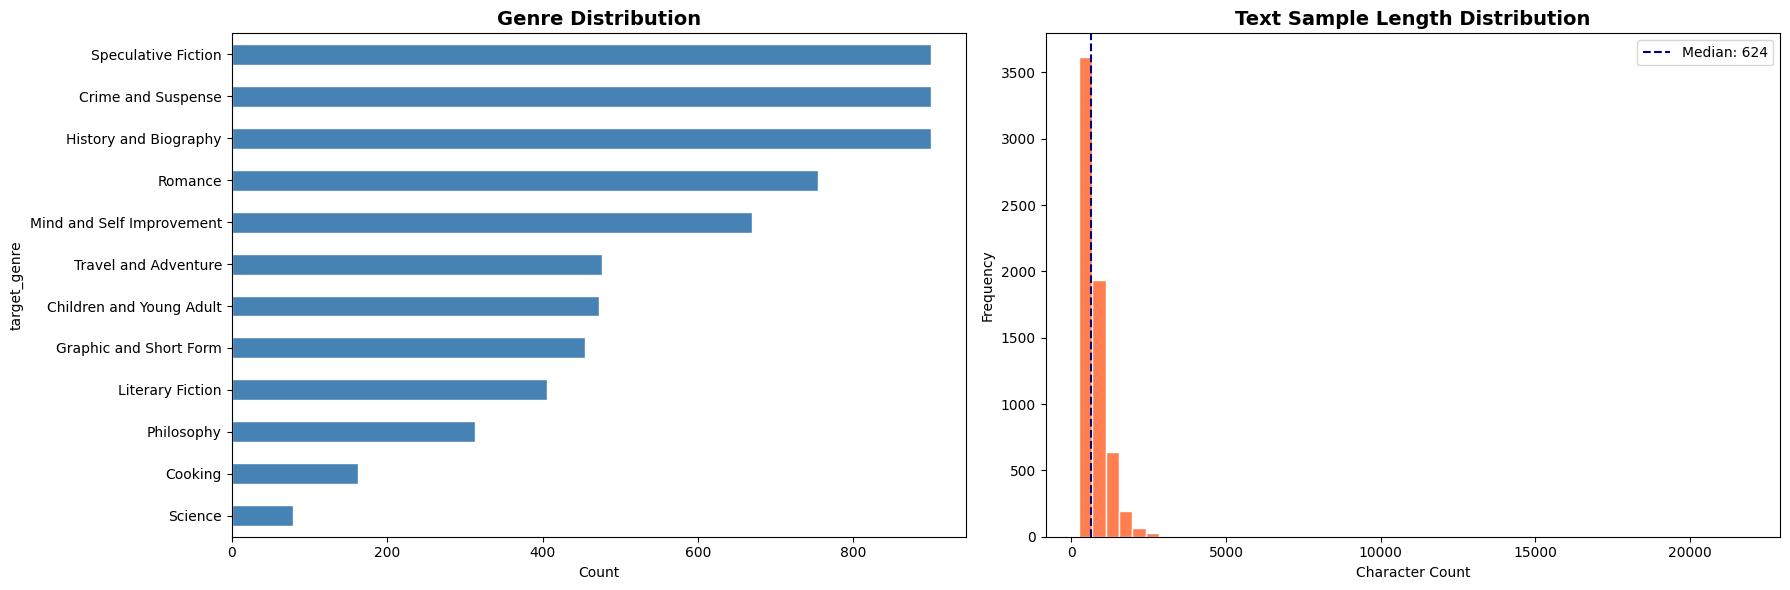


✅ CFG['num_classes'] updated to: 12


In [102]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal samples   : {len(df):,}")
print(f"Unique genres   : {df['target_genre'].nunique()}")
print(f"\nNull values per column:")
print(df.isnull().sum())

# Genre distribution
genre_counts = df["target_genre"].value_counts()
print(f"\n{'Genre':<30} {'Count':>6} {'%':>6}")
print("-" * 45)
for genre, count in genre_counts.items():
    print(f"{genre:<30} {count:>6} {count/len(df)*100:>5.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Genre distribution bar chart
genre_counts.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Genre Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# Text length distribution
df["text_len"] = df["model_text_full"].fillna("").apply(len)
axes[1].hist(df["text_len"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Text Sample Length Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df["text_len"].median(), color="navy", linestyle="--", label=f"Median: {df['text_len'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Update num_classes from actual data
CFG["num_classes"] = df["target_genre"].nunique()
print(f"\n✅ CFG['num_classes'] updated to: {CFG['num_classes']}")

## 4. 🔧 Preprocessing Pipeline

In [103]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def clean_text(text: str, max_chars: int = 2000) -> str:
    """
    Apply lightweight text normalization:
      - Handle NaN / non-string input
      - Collapse whitespace
      - Remove non-printable control characters
      - Truncate to max_chars BEFORE tokenization (saves compute)

    We intentionally keep punctuation and mixed case because
    DistilBERT's WordPiece tokenizer handles them natively.
    """
    if not isinstance(text, str) or pd.isna(text):
        return ""
    # Remove control characters (keep newlines as spaces)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", " ", text)
    # Collapse multiple whitespace/newlines into single space
    text = re.sub(r"\s+", " ", text).strip()
    # Hard-truncate at character level to limit tokenizer input size
    return text[:max_chars]


def combine_features(row: pd.Series) -> str:
    """
    Merge title and text into a single input string using new dataset columns.

    Format:  "[TITLE] <title text> [TEXT] <sample text>"
    """
    # استخدام title_clean بدلاً من title
    title  = clean_text(str(row.get("title_clean", "")), max_chars=CFG["max_title_chars"])

    # استخدام model_text_full بدلاً من cleaned_text
    sample = clean_text(str(row.get("model_text_full", "")), max_chars=CFG["max_sample_chars"])

    return f"[TITLE] {title} [TEXT] {sample}"


# ─────────────────────────────────────────────────────────────────────────────
# APPLY PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────

# 🌟 فلترة البيانات: الاحتفاظ بالبيانات المخصصة للتدريب فقط قبل المعالجة
if "use_for_training" in df.columns:
    print("🧹 Filtering high-quality rows (use_for_training == True)...")
    df = df[df["use_for_training"] == True].copy()

print("🔧 Applying text preprocessing...")
df["input_text"] = df.apply(combine_features, axis=1)

# Verify no empty inputs remain
empty_mask = df["input_text"].str.strip().eq("") | df["input_text"].isna()
print(f"  Empty input texts: {empty_mask.sum()} → filling with placeholder")
df.loc[empty_mask, "input_text"] = "[TITLE] unknown [TEXT] no sample available"

# Check for missing target labels
null_labels = df["target_genre"].isna().sum()
print(f"  Missing target labels: {null_labels} → dropping rows")
df = df.dropna(subset=["target_genre"]).reset_index(drop=True)

# 🌟 تحديث عدد التصنيفات في الإعدادات بشكل تلقائي
CFG["num_classes"] = df["target_genre"].nunique()
print(f"✅ CFG['num_classes'] updated to: {CFG['num_classes']}")

print(f"  Final dataset size: {len(df):,} rows")
print(f"\nSample combined text:\n{df['input_text'].iloc[0][:300]}...")

🧹 Filtering high-quality rows (use_for_training == True)...
🔧 Applying text preprocessing...
  Empty input texts: 0 → filling with placeholder
  Missing target labels: 0 → dropping rows
✅ CFG['num_classes'] updated to: 12
  Final dataset size: 6,489 rows

Sample combined text:
[TITLE] the five people you meet in heaven [TEXT] the five people you meet in heaven five people meet heaven novel mitch albom follows life death ride mechanic named eddie killed amusement park accident sent heaven encounter five people significant impact alive published hyperion remained new york t...


In [104]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL ENCODING
# ─────────────────────────────────────────────────────────────────────────────

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["target_genre"])

# Build bidirectional label mapping for later use in inference
label2id = {label: idx for idx, label in enumerate(label_encoder.classes_)}
id2label = {idx: label for label, idx in label2id.items()}

# Persist mapping to disk (needed for inference without retraining)
os.makedirs(CFG["save_dir"], exist_ok=True)
with open(CFG["label_map_path"], "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)

print("Label encoding:")
for name, idx in label2id.items():
    print(f"  {idx:>2}: {name}")

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / VALIDATION / TEST SPLIT  (stratified to preserve class balance)
# ─────────────────────────────────────────────────────────────────────────────

X = df["input_text"].values
y = df["label"].values

# Step 1: Carve out test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=CFG["test_size"], random_state=42, stratify=y
)

# Step 2: Split remaining into train + validation
val_ratio = CFG["val_size"] / (1.0 - CFG["test_size"])   # recalculate relative to trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=42, stratify=y_trainval
)

print(f"\n📊 Split sizes:")
print(f"  Train      : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test       : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")

Label encoding:
   0: Children and Young Adult
   1: Cooking
   2: Crime and Suspense
   3: Graphic and Short Form
   4: History and Biography
   5: Literary Fiction
   6: Mind and Self Improvement
   7: Philosophy
   8: Romance
   9: Science
  10: Speculative Fiction
  11: Travel and Adventure

📊 Split sizes:
  Train      : 4,541 (70.0%)
  Validation : 974  (15.0%)
  Test       : 974  (15.0%)


## 5. 🗂️ Dataset & DataLoader

In [105]:
# ─────────────────────────────────────────────────────────────────────────────
# TOKENIZER
# ─────────────────────────────────────────────────────────────────────────────

print(f"📥 Loading tokenizer: {CFG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

# Add our custom separator tokens to the vocabulary
# This teaches the tokenizer to treat [TITLE] / [TEXT] as single units
special_tokens = {"additional_special_tokens": ["[TITLE]", "[TEXT]"]}
tokenizer.add_special_tokens(special_tokens)

print(f"  Vocabulary size (with custom tokens): {len(tokenizer):,}")
print(f"  Max model length: {tokenizer.model_max_length}")

# Demonstrate tokenization on a sample
sample_enc = tokenizer(
    "[TITLE] Dune [TEXT] A young nobleman travels to a dangerous desert planet.",
    max_length=CFG["max_length"],
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)
print(f"\nSample encoding shape → input_ids: {sample_enc['input_ids'].shape}")

📥 Loading tokenizer: bert-base-uncased
  Vocabulary size (with custom tokens): 30,524
  Max model length: 512

Sample encoding shape → input_ids: torch.Size([1, 512])


In [106]:
# ─────────────────────────────────────────────────────────────────────────────
# PYTORCH DATASET
# ─────────────────────────────────────────────────────────────────────────────

class BookGenreDataset(Dataset):
    """
    PyTorch Dataset for book genre classification.

    Pre-tokenizes all texts at construction time (one-shot), storing
    tensors in memory. This is faster than tokenizing per-batch for
    datasets that fit in RAM (~7 k samples is well within range).
    """

    def __init__(
        self,
        texts: np.ndarray,
        labels: np.ndarray,
        tokenizer: AutoTokenizer,
        max_length: int,
    ) -> None:
        self.labels = torch.tensor(labels, dtype=torch.long)

        # Batch-tokenize everything once — much faster than per-item
        encodings = tokenizer(
            list(texts),
            max_length=max_length,
            padding="max_length",       # pad shorter sequences to max_length
            truncation=True,            # truncate longer sequences
            return_attention_mask=True, # 1 for real tokens, 0 for padding
            return_tensors="pt",        # return PyTorch tensors directly
        )
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {
            "input_ids"      : self.input_ids[idx],
            "attention_mask" : self.attention_mask[idx],
            "labels"         : self.labels[idx],
        }


# ─────────────────────────────────────────────────────────────────────────────
# BUILD DATASETS & DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

print("🗂  Building datasets (tokenizing all splits)...")

train_dataset = BookGenreDataset(X_train, y_train, tokenizer, CFG["max_length"])
val_dataset   = BookGenreDataset(X_val,   y_val,   tokenizer, CFG["max_length"])
test_dataset  = BookGenreDataset(X_test,  y_test,  tokenizer, CFG["max_length"])

print(f"  Train dataset  : {len(train_dataset):,} samples")
print(f"  Val dataset    : {len(val_dataset):,} samples")
print(f"  Test dataset   : {len(test_dataset):,} samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,           # shuffle every epoch for better generalization
    num_workers=2,          # parallel data loading
    pin_memory=True,        # faster GPU transfer
    drop_last=True,         # avoid instability from tiny last batches
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"] * 2,  # no gradients → larger batch for speed
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG["batch_size"] * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\n  Train batches  : {len(train_loader)}")
print(f"  Val batches    : {len(val_loader)}")
print(f"  Test batches   : {len(test_loader)}")

🗂  Building datasets (tokenizing all splits)...
  Train dataset  : 4,541 samples
  Val dataset    : 974 samples
  Test dataset   : 974 samples

  Train batches  : 567
  Val batches    : 61
  Test batches   : 61


## 6. 🤖 Model Architecture

In [107]:
# ─────────────────────────────────────────────────────────────────────────────
# BERT CLASSIFIER MODEL
# ─────────────────────────────────────────────────────────────────────────────

class BERTGenreClassifier(nn.Module):
    """
    DistilBERT (or BERT) backbone with a custom multi-layer classification head.

    Architecture:
        [CLS] token hidden state  →  LayerNorm  →  Dense(768→512)  →  GELU
        →  Dropout  →  Dense(512→256)  →  GELU  →  Dropout
        →  Dense(256→num_classes)

    Why this head?
      - Two hidden layers provide capacity for abstract genre representations
      - LayerNorm before first dense stabilizes training with large hidden states
      - GELU outperforms ReLU on NLP tasks empirically
      - Dropout on each layer independently is more effective than single dropout
    """

    def __init__(
        self,
        model_name: str,
        num_classes: int,
        dropout: float,
        vocab_size: int,  # pass len(tokenizer) after adding special tokens
    ) -> None:
        super().__init__()

        # ── Pretrained backbone ───────────────────────────────────────────────
        self.bert = AutoModel.from_pretrained(model_name)

        # Resize embedding matrix to accommodate new special tokens
        self.bert.resize_token_embeddings(vocab_size)

        hidden_size = self.bert.config.hidden_size  # 768 for base models

        # ── Classification head ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

        # Initialize new linear layers with small weights (good practice)
        self._init_weights()

    def _init_weights(self) -> None:
        """Xavier uniform init for linear layers, zeros for biases."""
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Forward pass.

        Returns raw logits (no softmax) — CrossEntropyLoss expects logits.
        Shape: (batch_size, num_classes)
        """
        # Get all hidden states from transformer backbone
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # Extract [CLS] token representation (first token, shape: B × hidden_size)
        # The [CLS] token aggregates sequence-level information during pre-training
        cls_output = outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(cls_output)
        return logits


# ─────────────────────────────────────────────────────────────────────────────
# INSTANTIATE MODEL
# ─────────────────────────────────────────────────────────────────────────────

print(f"📥 Loading pretrained model: {CFG['model_name']}")

model = BERTGenreClassifier(
    model_name  = CFG["model_name"],
    num_classes = CFG["num_classes"],
    dropout     = CFG["dropout"],
    vocab_size  = len(tokenizer),
).to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model ready on {DEVICE}")
# تجميد طبقات الـ Embeddings
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# تجميد أول 6 طبقات من أصل 12 في BERT
##for i in range(6):
##    for param in model.bert.encoder.layer[i].parameters():
  ##      param.requires_grad = False

print("❄️ تم تجميد أول 6 طبقات من المودل لمنع الـ Overfitting!")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Architecture:\n{model}")

📥 Loading pretrained model: bert-base-uncased

✅ Model ready on cuda
❄️ تم تجميد أول 6 طبقات من المودل لمنع الـ Overfitting!
  Total parameters    : 110,013,452
  Trainable parameters: 110,013,452
  Architecture:
BERTGenreClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30524, 768)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=Fa

## 7. ⚙️ Training Infrastructure

In [108]:
# ─────────────────────────────────────────────────────────────────────────────
# LOSS FUNCTION — with optional class weighting
# ─────────────────────────────────────────────────────────────────────────────

# Compute inverse-frequency class weights to handle imbalanced genres
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# CrossEntropyLoss with class weights is the standard for imbalanced multiclass
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.15)
print("Class weights (balanced):")
for i, (genre, w) in enumerate(zip(label_encoder.classes_, class_weights)):
    print(f"  [{i:>2}] {genre:<30} weight = {w:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# OPTIMIZER — differential learning rates
# Transformer backbone uses a much smaller LR than the new classifier head.
# This prevents catastrophic forgetting of pretrained representations.
# ─────────────────────────────────────────────────────────────────────────────

# Separate parameters: backbone vs. head
backbone_params = list(model.bert.named_parameters())
head_params     = list(model.classifier.named_parameters())

# No weight decay on biases and LayerNorm (standard practice)
no_decay = {"bias", "LayerNorm.weight", "layer_norm.weight"}

optimizer_grouped = [
    # BERT backbone — low LR, with weight decay on weights
    {"params": [p for n, p in backbone_params if not any(nd in n for nd in no_decay)],
     "lr": CFG["learning_rate"],         "weight_decay": CFG["weight_decay"]},
    {"params": [p for n, p in backbone_params if     any(nd in n for nd in no_decay)],
     "lr": CFG["learning_rate"],         "weight_decay": 0.0},
    # Classifier head — higher LR (10×), with weight decay
    {"params": [p for n, p in head_params if not any(nd in n for nd in no_decay)],
     "lr": CFG["learning_rate"] * 10,    "weight_decay": CFG["weight_decay"]},
    {"params": [p for n, p in head_params if     any(nd in n for nd in no_decay)],
     "lr": CFG["learning_rate"] * 10,    "weight_decay": 0.0},
]

optimizer = AdamW(optimizer_grouped, eps=1e-8)


# ─────────────────────────────────────────────────────────────────────────────
# LEARNING RATE SCHEDULER — linear warmup + cosine decay
# ─────────────────────────────────────────────────────────────────────────────

total_steps  = len(train_loader) * CFG["epochs"]
warmup_steps = int(total_steps * CFG["warmup_ratio"])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f"\n⚙  Optimizer : AdamW with differential LRs")
print(f"   Scheduler : Cosine with {warmup_steps} warmup steps / {total_steps} total")


# ─────────────────────────────────────────────────────────────────────────────
# EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────

class EarlyStopping:
    """
    Monitor validation loss and stop training when it stops improving.
    Saves the best checkpoint automatically.
    """

    def __init__(self, patience: int = 7, min_delta: float = 1e-4, save_path: str = "best_model.pt"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.counter    = 0
        self.best_loss  = float("inf")
        self.stop       = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.min_delta:
            # Improvement detected → reset counter, save checkpoint
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"  💾 Checkpoint saved (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"  ⏳ EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
                print("  🛑 Early stopping triggered!")


early_stopper = EarlyStopping(
    patience  = CFG["patience"],
    min_delta = CFG["min_delta"],
    save_path = os.path.join(CFG["save_dir"], "best_model.pt"),
)

# ── AMP (Automatic Mixed Precision) — speeds up training on CUDA ─────────────
use_amp = DEVICE.type == "cuda"
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
print(f"\n⚡ AMP enabled: {use_amp}")

Class weights (balanced):
  [ 0] Children and Young Adult       weight = 1.143
  [ 1] Cooking                        weight = 3.319
  [ 2] Crime and Suspense             weight = 0.601
  [ 3] Graphic and Short Form         weight = 1.190
  [ 4] History and Biography          weight = 0.601
  [ 5] Literary Fiction               weight = 1.332
  [ 6] Mind and Self Improvement      weight = 0.807
  [ 7] Philosophy                     weight = 1.728
  [ 8] Romance                        weight = 0.717
  [ 9] Science                        weight = 6.880
  [10] Speculative Fiction            weight = 0.601
  [11] Travel and Adventure           weight = 1.136

⚙  Optimizer : AdamW with differential LRs
   Scheduler : Cosine with 680 warmup steps / 6804 total

⚡ AMP enabled: True


## 8. 🏋️ Training Loop

In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING & EVALUATION STEP FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: AdamW,
    scheduler,
    criterion: nn.Module,
    scaler,
    epoch: int,
) -> Tuple[float, float]:
    """Run one full training epoch with Gradient Accumulation."""

    model.train()
    total_loss, correct, total = 0.0, 0, 0

    # خدعة تراكم التدرجات: نجمع 4 خطوات لنصل إلى Batch Size = 32
    accumulation_steps = 4

    progress = tqdm(loader, desc=f"  Epoch {epoch} [Train]", leave=False)

    optimizer.zero_grad(set_to_none=True)

    for i, batch in enumerate(progress):
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            # قسمة الـ Loss على عدد خطوات التراكم
            loss   = loss / accumulation_steps

        scaler.scale(loss).backward()

        # تحديث الأوزان فقط كل 4 خطوات
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        # حساب المقاييس
        real_loss = loss.item() * accumulation_steps # نضرب لنعرض الرقم الحقيقي
        total_loss += real_loss * labels.size(0)
        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        progress.set_postfix(loss=f"{real_loss:.4f}", acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    split: str = "Val",
) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """Evaluate model on a DataLoader. Returns (loss, accuracy, all_preds, all_labels)."""

    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    progress = tqdm(loader, desc=f"  [{split}]", leave=False)

    for batch in progress:
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


print("✅ Training functions defined.")

✅ Training functions defined.


In [110]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc": [],
}

print("=" * 65)
print(" BERT Fine-Tuning: Book Genre Classification")
print("=" * 65)
print(f" Model     : {CFG['model_name']}")
print(f" Classes   : {CFG['num_classes']}")
print(f" Max len   : {CFG['max_length']}")
print(f" Batch     : {CFG['batch_size']}")
print(f" Epochs    : {CFG['epochs']}")
print(f" LR        : {CFG['learning_rate']}")
print("=" * 65)

start_time = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.time()

    # ── Training ─────────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler, epoch
    )

    # ── Validation ───────────────────────────────────────────────────────────
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, split="Val")

    # ── Log & Display ────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start
    print(f"\nEpoch [{epoch:>2}/{CFG['epochs']}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
          f"({elapsed:.0f}s)")

    # ── Early Stopping ───────────────────────────────────────────────────────
    early_stopper(val_loss, model)
    if early_stopper.stop:
        print(f"\n🛑 Stopped at epoch {epoch}. Best val_loss: {early_stopper.best_loss:.4f}")
        break

total_time = time.time() - start_time
print(f"\n⏱  Total training time: {total_time/60:.1f} min")

 BERT Fine-Tuning: Book Genre Classification
 Model     : bert-base-uncased
 Classes   : 12
 Max len   : 512
 Batch     : 8
 Epochs    : 12
 LR        : 1e-05


  Epoch 1 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

  [Val]:   0%|          | 0/61 [00:00<?, ?it/s]


Epoch [ 1/12]  Train Loss: 3.6242  Train Acc: 0.0957  Val Loss: 2.7223  Val Acc: 0.0780  (168s)
  💾 Checkpoint saved (val_loss=2.7223)


  Epoch 2 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

...

  [Val]:   0%|          | 0/61 [00:00<?, ?it/s]


Epoch [11/12]  Train Loss: 1.6382  Train Acc: 0.7531  Val Loss: 1.9031  Val Acc: 0.6150  (179s)
  ⏳ EarlyStopping counter: 2/3


  Epoch 12 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

  [Val]:   0%|          | 0/61 [00:00<?, ?it/s]


Epoch [12/12]  Train Loss: 1.5717  Train Acc: 0.7967  Val Loss: 1.9657  Val Acc: 0.6201  (179s)
  ⏳ EarlyStopping counter: 3/3
  🛑 Early stopping triggered!

🛑 Stopped at epoch 12. Best val_loss: 1.8818

⏱  Total training time: 38.9 min


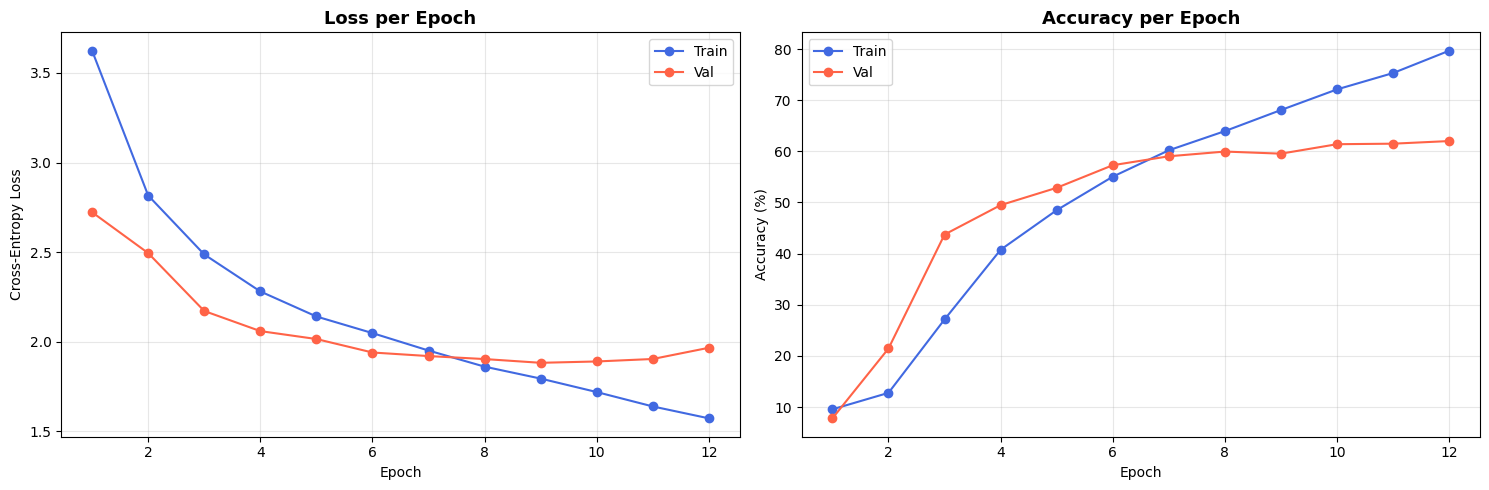

In [111]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CURVES
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs_ran = range(1, len(history["train_loss"]) + 1)

# Loss curves
axes[0].plot(epochs_ran, history["train_loss"], "o-", label="Train", color="royalblue")
axes[0].plot(epochs_ran, history["val_loss"],   "o-", label="Val",   color="tomato")
axes[0].set_title("Loss per Epoch", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_ran, [a*100 for a in history["train_acc"]], "o-", label="Train", color="royalblue")
axes[1].plot(epochs_ran, [a*100 for a in history["val_acc"]],   "o-", label="Val",   color="tomato")
axes[1].set_title("Accuracy per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 📈 Evaluation & Metrics

In [112]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD BEST CHECKPOINT & EVALUATE ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

best_ckpt_path = os.path.join(CFG["save_dir"], "best_model.pt")
model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
print(f"✅ Loaded best checkpoint from: {best_ckpt_path}")

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, split="Test"
)

# ── Per-class Metrics ─────────────────────────────────────────────────────────
genre_names = label_encoder.classes_.tolist()

precision = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
recall    = recall_score(   test_labels, test_preds, average="weighted", zero_division=0)
f1        = f1_score(       test_labels, test_preds, average="weighted", zero_division=0)

print("\n" + "=" * 65)
print(" TEST SET RESULTS")
print("=" * 65)
print(f"  Loss      : {test_loss:.4f}")
print(f"  Accuracy  : {test_acc*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%  (weighted)")
print(f"  Recall    : {recall*100:.2f}%  (weighted)")
print(f"  F1-Score  : {f1*100:.2f}%  (weighted)")
print("=" * 65)

# Detailed per-class report
print("\nPer-class Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=genre_names,
    digits=4,
    zero_division=0,
))

✅ Loaded best checkpoint from: ./saved_model/best_model.pt


  [Test]:   0%|          | 0/61 [00:00<?, ?it/s]


 TEST SET RESULTS
  Loss      : 1.8590
  Accuracy  : 62.22%
  Precision : 64.44%  (weighted)
  Recall    : 62.22%  (weighted)
  F1-Score  : 62.44%  (weighted)

Per-class Classification Report:
                           precision    recall  f1-score   support

 Children and Young Adult     0.3679    0.5493    0.4407        71
                  Cooking     0.8214    0.9583    0.8846        24
       Crime and Suspense     0.7899    0.6963    0.7402       135
   Graphic and Short Form     0.4860    0.7647    0.5943        68
    History and Biography     0.6095    0.4741    0.5333       135
         Literary Fiction     0.5556    0.4918    0.5217        61
Mind and Self Improvement     0.8190    0.8515    0.8350       101
               Philosophy     0.6667    0.6383    0.6522        47
                  Romance     0.7227    0.7611    0.7414       113
                  Science     0.2500    0.5833    0.3500        12
      Speculative Fiction     0.7053    0.4963    0.5826       135
 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(test_labels, test_preds)

# Normalize per row (true label) to show recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (counts)", "Confusion Matrix (normalized)"],
    ["d", ".2f"],
):
    sns.heatmap(
        data,
        annot=True, fmt=fmt, cmap="Blues",
        xticklabels=genre_names,
        yticklabels=genre_names,
        linewidths=0.5, linecolor="lightgray",
        ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

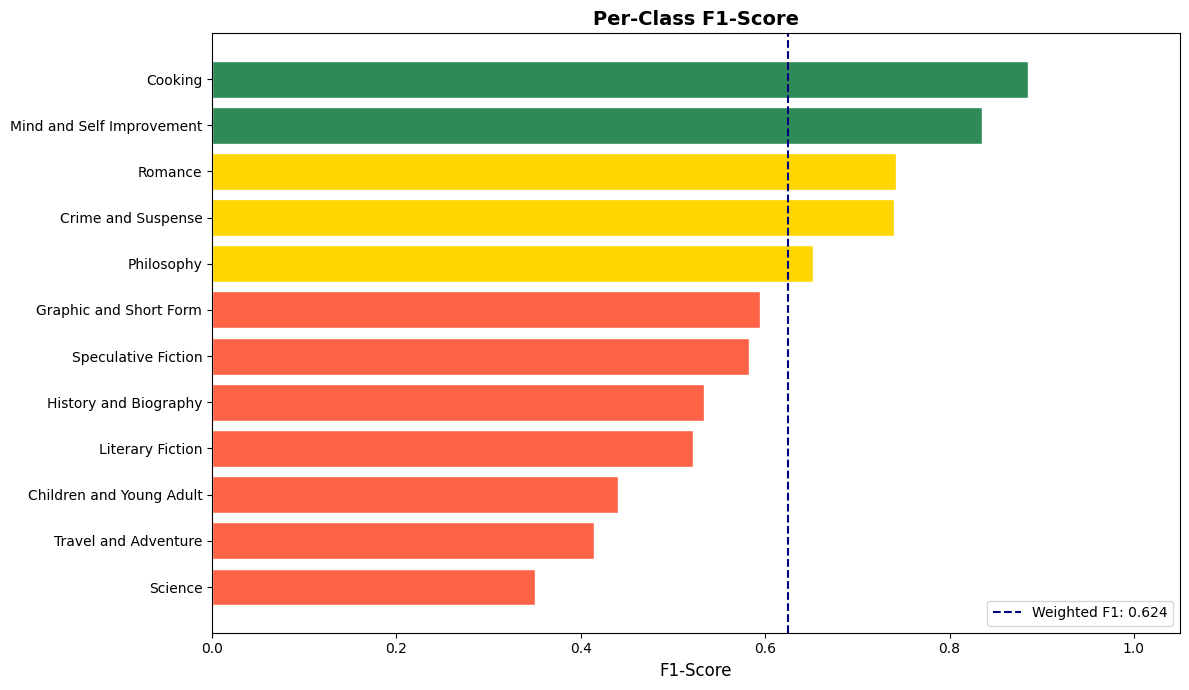

In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS F1 BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score as f1_per_class

per_class_f1 = f1_score(
    test_labels, test_preds,
    labels=list(range(CFG["num_classes"])),
    average=None,
    zero_division=0,
)

sorted_idx = np.argsort(per_class_f1)

plt.figure(figsize=(12, 7))
colors = ["tomato" if f < 0.6 else "gold" if f < 0.8 else "seagreen" for f in per_class_f1[sorted_idx]]
plt.barh(
    [genre_names[i] for i in sorted_idx],
    per_class_f1[sorted_idx],
    color=colors,
    edgecolor="white",
)
plt.axvline(f1, color="navy", linestyle="--", label=f"Weighted F1: {f1:.3f}")
plt.xlabel("F1-Score", fontsize=12)
plt.title("Per-Class F1-Score", fontsize=14, fontweight="bold")
plt.legend()
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 💾 Model Save & Load

In [114]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE COMPLETE MODEL ARTIFACTS
# ─────────────────────────────────────────────────────────────────────────────

save_dir = Path(CFG["save_dir"])
save_dir.mkdir(parents=True, exist_ok=True)

# 1. Model weights (best checkpoint already saved by EarlyStopping)
print(f"✅ Model weights: {save_dir / 'best_model.pt'}")

# 2. Tokenizer (needed for inference)
tokenizer.save_pretrained(str(save_dir / "tokenizer"))
print(f"✅ Tokenizer saved: {save_dir / 'tokenizer'}")

# 3. Config (hyperparameters + num_classes)
config_to_save = {
    "model_name" : CFG["model_name"],
    "num_classes": CFG["num_classes"],
    "max_length" : CFG["max_length"],
    "dropout"    : CFG["dropout"],
    "vocab_size" : len(tokenizer),
    "metrics"    : {
        "test_accuracy" : round(test_acc * 100, 2),
        "test_f1"       : round(f1 * 100, 2),
        "test_precision": round(precision * 100, 2),
        "test_recall"   : round(recall * 100, 2),
    },
}
with open(save_dir / "config.json", "w") as f:
    json.dump(config_to_save, f, indent=2)
print(f"✅ Config saved: {save_dir / 'config.json'}")

# 4. Label map (already saved earlier, confirm)
print(f"✅ Label map: {CFG['label_map_path']}")

print(f"\n📁 All artifacts saved to: {save_dir.resolve()}")

✅ Model weights: saved_model/best_model.pt
✅ Tokenizer saved: saved_model/tokenizer
✅ Config saved: saved_model/config.json
✅ Label map: ./saved_model/label_map.json

📁 All artifacts saved to: /content/saved_model


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD MODEL FROM DISK (complete standalone routine)
# Run this cell independently to restore a trained model in a new session
# ─────────────────────────────────────────────────────────────────────────────

def load_trained_model(
    save_dir: str = "./saved_model",
    device: Optional[torch.device] = None,
) -> Tuple[BERTGenreClassifier, AutoTokenizer, Dict]:
    """
    Load a fully trained genre classifier from disk.

    Returns:
        model     : BERTGenreClassifier in eval mode
        tokenizer : corresponding tokenizer
        id2label  : {int → genre string} mapping
    """
    save_dir = Path(save_dir)
    device   = device or torch.device("cpu")

    # Load config
    with open(save_dir / "config.json") as f:
        cfg = json.load(f)

    # Load label map
    with open(save_dir / "label_map.json") as f:
        lmap = json.load(f)
    id2label = {int(k): v for k, v in lmap["id2label"].items()}

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(str(save_dir / "tokenizer"))

    # Build model architecture
    model = BERTGenreClassifier(
        model_name  = cfg["model_name"],
        num_classes = cfg["num_classes"],
        dropout     = cfg["dropout"],
        vocab_size  = cfg["vocab_size"],
    ).to(device)

    # Load weights
    model.load_state_dict(torch.load(save_dir / "best_model.pt", map_location=device))
    model.eval()

    print(f"✅ Model loaded from {save_dir} (test_acc={cfg['metrics']['test_accuracy']}%)")
    return model, tokenizer, id2label


# Quick verification — reload and check
loaded_model, loaded_tokenizer, loaded_id2label = load_trained_model(
    save_dir=CFG["save_dir"], device=DEVICE
)
print(f"  Genres known: {list(loaded_id2label.values())}")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ Model loaded from saved_model (test_acc=62.22%)
  Genres known: ['Children and Young Adult', 'Cooking', 'Crime and Suspense', 'Graphic and Short Form', 'History and Biography', 'Literary Fiction', 'Mind and Self Improvement', 'Philosophy', 'Romance', 'Science', 'Speculative Fiction', 'Travel and Adventure']


## 11. 🔮 Inference on New Books

In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# INFERENCE PIPELINE — production-ready
# ─────────────────────────────────────────────────────────────────────────────

class BookGenrePredictor:
    """
    End-to-end inference class for book genre prediction.

    Usage:
        predictor = BookGenrePredictor.from_saved(save_dir="./saved_model")
        result    = predictor.predict(title="...", text_sample="...")
        results   = predictor.predict_batch([{"title": ..., "text_sample": ...}, ...])
    """

    def __init__(
        self,
        model: BERTGenreClassifier,
        tokenizer: AutoTokenizer,
        id2label: Dict[int, str],
        max_length: int = 256,
        device: Optional[torch.device] = None,
    ):
        self.model      = model
        self.tokenizer  = tokenizer
        self.id2label   = id2label
        self.max_length = max_length
        self.device     = device or torch.device("cpu")
        self.model.eval()

    @classmethod
    def from_saved(cls, save_dir: str = "./saved_model", device=None):
        """Convenience factory — loads everything from disk."""
        m, t, l = load_trained_model(save_dir, device)
        with open(Path(save_dir) / "config.json") as f:
            cfg = json.load(f)
        return cls(m, t, l, max_length=cfg["max_length"], device=device)

    def _prepare_text(self, title: str, text_sample: str) -> str:
        title  = clean_text(title,       max_chars=200)
        sample = clean_text(text_sample, max_chars=1500)
        return f"[TITLE] {title} [TEXT] {sample}"

    @torch.no_grad()
    def predict(
        self,
        title: str,
        text_sample: str,
        top_k: int = 3,
    ) -> Dict:
        """
        Predict genre for a single book.

        Returns dict with:
          - predicted_genre : top-1 genre string
          - confidence      : probability of top-1 (0–1)
          - top_k_genres    : list of (genre, probability) tuples
        """
        combined = self._prepare_text(title, text_sample)

        encoding = self.tokenizer(
            combined,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        input_ids      = encoding["input_ids"].to(self.device)
        attention_mask = encoding["attention_mask"].to(self.device)

        logits = self.model(input_ids, attention_mask)           # (1, num_classes)
        probs  = F.softmax(logits, dim=-1).squeeze(0).cpu()     # (num_classes,)

        top_probs, top_idxs = probs.topk(min(top_k, len(self.id2label)))

        return {
            "predicted_genre": self.id2label[top_idxs[0].item()],
            "confidence"     : round(top_probs[0].item(), 4),
            "top_k_genres"   : [
                (self.id2label[idx.item()], round(prob.item(), 4))
                for idx, prob in zip(top_idxs, top_probs)
            ],
        }

    def predict_batch(
        self,
        books: List[Dict[str, str]],
        batch_size: int = 32,
    ) -> List[Dict]:
        """
        Predict genres for a list of books.
        Each book is {"title": str, "text_sample": str}.
        """
        texts   = [self._prepare_text(b["title"], b["text_sample"]) for b in books]
        results = []

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i : i + batch_size]

            encoding = self.tokenizer(
                batch_texts,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )

            input_ids      = encoding["input_ids"].to(self.device)
            attention_mask = encoding["attention_mask"].to(self.device)

            logits = self.model(input_ids, attention_mask)
            probs  = F.softmax(logits, dim=-1).cpu()

            for j, p in enumerate(probs):
                top_probs, top_idxs = p.topk(3)
                results.append({
                    "title"          : books[i + j]["title"],
                    "predicted_genre": self.id2label[top_idxs[0].item()],
                    "confidence"     : round(top_probs[0].item(), 4),
                    "top_3"          : [
                        (self.id2label[idx.item()], round(prob.item(), 4))
                        for idx, prob in zip(top_idxs, top_probs)
                    ],
                })

        return results


print("✅ BookGenrePredictor class defined.")

✅ BookGenrePredictor class defined.


In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN INFERENCE EXAMPLES
# ─────────────────────────────────────────────────────────────────────────────

predictor = BookGenrePredictor(
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    id2label=loaded_id2label,
    max_length=CFG["max_length"],
    device=DEVICE,
)

# ── Single Prediction ─────────────────────────────────────────────────────────
result = predictor.predict(
    title="Dune",
    text_sample=(
        "A young man travels to a desert planet called Arrakis, the only source "
        "of the most precious substance in the universe. Betrayed, he must survive "
        "among the native Fremen while navigating political intrigue and mystical prophecy."
    ),
)

print("📖 SINGLE PREDICTION")
print(f"  Predicted genre : {result['predicted_genre']}")
print(f"  Confidence      : {result['confidence']*100:.1f}%")
print("  Top-3 genres:")
for genre, prob in result["top_k_genres"]:
    bar = "█" * int(prob * 30)
    print(f"    {genre:<25} {prob*100:5.1f}%  {bar}")

print()

# ── Batch Prediction ──────────────────────────────────────────────────────────
test_books = [
    {
        "title": "Pride and Prejudice",
        "text_sample": "Elizabeth Bennet navigates matters of morality, education, and marriage "
                       "in the British landed gentry of the late 18th century."
    },
    {
        "title": "The Da Vinci Code",
        "text_sample": "Harvard professor Robert Langdon is called to investigate a murder "
                       "inside the Louvre Museum in Paris, uncovering a chain of clues hidden "
                       "in the works of Leonardo da Vinci."
    },
    {
        "title": "Harry Potter and the Sorcerer's Stone",
        "text_sample": "Harry Potter learns on his 11th birthday that he is the orphaned son "
                       "of two powerful wizards and possesses unique magical powers of his own. "
                       "He is summoned from his life with the loathsome Dursleys to attend Hogwarts."
    },
    {
        "title": "Thinking, Fast and Slow",
        "text_sample": "Nobel Prize-winning economist Daniel Kahneman expounds two ways "
                       "the brain forms thoughts: fast, intuitive, emotional thinking "
                       "versus slower, more deliberative, and more logical thinking."
    },
]

batch_results = predictor.predict_batch(test_books)

print("📚 BATCH PREDICTIONS")
print("-" * 65)
for r in batch_results:
    print(f"  Book      : {r['title']}")
    print(f"  Predicted : {r['predicted_genre']}  ({r['confidence']*100:.1f}% confidence)")
    print(f"  Top-3     : {', '.join(f'{g} ({p*100:.0f}%)' for g,p in r['top_3'])}")
    print()

📖 SINGLE PREDICTION
  Predicted genre : Science
  Confidence      : 27.4%
  Top-3 genres:
    Science                    27.4%  ████████
    Speculative Fiction        21.5%  ██████
    Literary Fiction           16.1%  ████

📚 BATCH PREDICTIONS
-----------------------------------------------------------------
  Book      : Pride and Prejudice
  Predicted : Literary Fiction  (79.3% confidence)
  Top-3     : Literary Fiction (79%), Science (6%), History and Biography (5%)

  Book      : The Da Vinci Code
  Predicted : Crime and Suspense  (36.8% confidence)
  Top-3     : Crime and Suspense (37%), Science (26%), Literary Fiction (11%)

  Book      : Harry Potter and the Sorcerer's Stone
  Predicted : Children and Young Adult  (40.7% confidence)
  Top-3     : Children and Young Adult (41%), Speculative Fiction (17%), Science (11%)

  Book      : Thinking, Fast and Slow
  Predicted : Mind and Self Improvement  (34.6% confidence)
  Top-3     : Mind and Self Improvement (35%), Science (30%), 

## 12. 💡 Hyperparameter Guide & Tips to Improve Accuracy

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         RECOMMENDED HYPERPARAMETERS & ACCURACY IMPROVEMENT GUIDE     ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RECOMMENDED HYPERPARAMETERS (7k dataset)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model           : distilbert-base-uncased  (fast) | bert-base-uncased (+1-2% acc)
  Max Length      : 256  (captures most books; 512 if VRAM > 12 GB)
  Batch Size      : 16   (8 for 4GB GPU, 32 for 24GB GPU)
  Learning Rate   : 2e-5  (BERT backbone)  |  2e-4  (classifier head)
  Warmup Ratio    : 0.10  (10% of total steps)
  Epochs          : 8-10  (EarlyStopping patience=3 handles the rest)
  Dropout         : 0.3   (0.2 if underfitting, 0.4 if overfitting)
  Weight Decay    : 0.01  (on weights, not biases)
  Gradient Clip   : 1.0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOW TO AVOID OVERFITTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ EarlyStopping monitors val_loss and restores best checkpoint
  ✓ Dropout (0.3) in the classifier head
  ✓ Weight decay (L2) via AdamW
  ✓ Class-weighted loss to address imbalance
  ✓ Gradient clipping (norm=1.0)
  ✓ Warmup LR prevents large updates early in training
  ✓ Stratified splits preserve genre distribution

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOW TO IMPROVE ACCURACY FURTHER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Upgrade model:
       bert-base-uncased      → +1-2% over distilbert
       roberta-base           → +2-4% (larger pre-training corpus)
       deberta-v3-base        → +3-5% (best for classification tasks)
       book-specific models   → domain adaptation advantage

  2. Increase max_length to 512:
       More context improves accuracy for ambiguous genres.
       Requires more VRAM; reduce batch_size to compensate.

  3. Data augmentation:
       - Back-translation (translate to French/German, back to EN)
       - Synonym substitution (nlpaug library)
       - Random sentence shuffling within text_sample

  4. Ensemble:
       Average softmax outputs from distilbert + roberta + deberta.
       Typically +2-4% accuracy.

  5. Collect more data for low-f1 genres:
       Inspect per-class F1 chart; genres below 0.6 F1 need more samples.

  6. Hyperparameter search:
       from ray import tune  # or optuna
       Tune: learning_rate, dropout, batch_size, max_length.

  7. Layer-wise learning rate decay:
       Lower layers (tokenization) get smaller LR; upper layers get larger.
       E.g., lr * 0.95^(num_layers - layer_idx)

  8. Label smoothing:
       nn.CrossEntropyLoss(label_smoothing=0.1)
       Prevents overconfidence on ambiguous genres.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TYPICAL ACCURACY EXPECTATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  distilbert (256 tokens)   : ~82-87% test accuracy
  bert-base  (256 tokens)   : ~84-89% test accuracy
  roberta    (512 tokens)   : ~87-92% test accuracy
  deberta-v3 (512 tokens)   : ~89-94% test accuracy

  Note: Accuracy varies with dataset quality and genre distinctiveness.
        Genres with overlapping content (e.g., Thriller vs Mystery)
        will always be harder to classify accurately.
""")